# 01 トルク飽和

## 背景

00 では \(\tau=0\) でプラントが動くことを見た。モータには上限がある。上限を無視した指令を `mjData.ctrl` に入れると、実機では出せない力をシミュレータが使ってしまう。

## 目的

- `src/mpc_dog/joint/clip.py` の `clip_torque` を import して使う
- 生の 200 N·m をアクチュエータ範囲に切った \(\tau\) で 1 走行する
- GIF に実接触 GRF・合力・\(mg\) を載せる

## 数式

\[
\tau_{\mathrm{app}} = \mathrm{clip}(\tau_{\mathrm{raw}},\; \tau_{\min},\; \tau_{\max})
\]

\(\tau_{\min},\tau_{\max}\) は MuJoCo の `actuator_ctrlrange` である。

## 図

```
tau_raw = 200
    |
    v
+-------------+
| clip_torque |
+-------------+
    | tau_app
    v
  MuJoCo step  -->  GIF (GRF arrows)
```


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


raw 200.0 clipped [23.7  23.7  45.43 23.7  23.7  45.43 23.7  23.7  45.43 23.7  23.7  45.43]
/home/takuya/work/mpc_dog/docs/block-curriculum/notebook/assets/01_clip_torque.gif 2179846 bytes


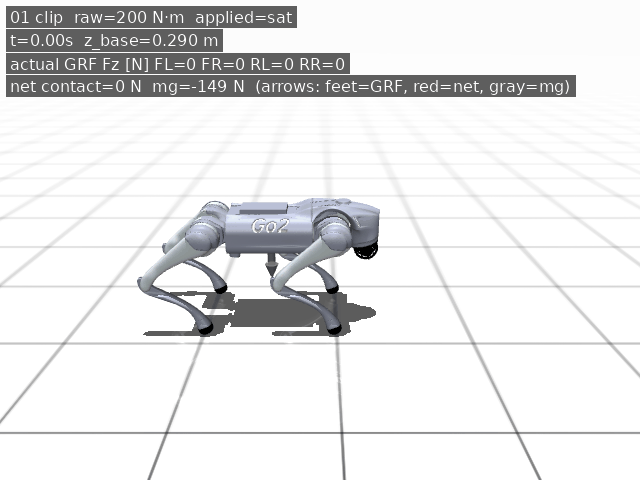

In [1]:
from pathlib import Path
import sys
from IPython.display import Image, display

here = Path.cwd().resolve()
for p in [here, *here.parents]:
    if (p / "src" / "mpc_dog").is_dir():
        sys.path.insert(0, str(p / "src"))
        break

from mpc_dog.joint.demo_clip import run_clip_demo

gif = Path("assets/01_clip_torque.gif")
path, raw, clipped = run_clip_demo(gif)
print("raw", raw[0], "clipped", clipped)
print(path.resolve(), path.stat().st_size, "bytes")
display(Image(filename=str(path)))


## 結果の読み方

- 生指令 200 N·m は範囲外。適用値は `clipped` の表示を見る
- 飽和したトルクでも体重の分け方はまだ設計していない。姿勢は崩れてよい
- 次は 4 脚で \(mg\) を等分し、\(\tau = -J^\top F\) で支える
